In [1]:
#Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
#Loading clean datasets
df = pd.read_csv('/content/cleaned_fleet_delay.csv')
df.columns = df.columns.str.strip()

print(df.shape)
print(df.head())
print(df.columns.tolist())

(3925, 53)
          Inc.#        Date Status Bugle Mgr              Bugle Mgr Title  \
0  480134220401  2022-04-01      A      MHB2          HITACHI - CLASS 801   
1  485541220403  2022-04-03      A      MHBK          YARD - CRAIGENTINNY   
2  485877220403  2022-04-03      A      MHB1          HITACHI - CLASS 800   
3  487346220404  2022-04-04      A      MHB1          HITACHI - CLASS 800   
4  488234220404  2022-04-04      A      MHBA  FLEET - CLASS 91 LOCOMOTIVE   

  Trust Mgr NR Mgr Cause Root Cause     Root Cause Descrip.  ... PPM Fails  \
0      MHB2   OQIE    MN    Unknown   No Root Cause entered  ...      0.00   
1      MHBK   OQL9    MU    Unknown   No Root Cause entered  ...      0.00   
2      MHB1   OQI8    MY       MY05  Class 800/801 Couplers  ...      0.00   
3      MHB1   OQI8    M7       M703          PASSENGER DOOR  ...      0.00   
4      MHBA   OQIJ    MB    Unknown   No Root Cause entered  ...      5.94   

   Sect1 Region.                Sect2       Day 8  NR KPI

In [3]:
#Basic checks
print(df.info())
print(df.isnull().sum().sort_values(ascending=False).head(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3925 entries, 0 to 3924
Data columns (total 53 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Inc.#                 3925 non-null   int64  
 1   Date                  3925 non-null   object 
 2   Status                3925 non-null   object 
 3   Bugle Mgr             3925 non-null   object 
 4   Bugle Mgr Title       3925 non-null   object 
 5   Trust Mgr             3925 non-null   object 
 6   NR Mgr                3925 non-null   object 
 7   Cause                 3925 non-null   object 
 8   Root Cause            3925 non-null   object 
 9   Root Cause Descrip.   3925 non-null   object 
 10  Incid. Location       3925 non-null   object 
 11  Comment               3925 non-null   object 
 12  Equip.                3925 non-null   object 
 13  Tot. Mins             3925 non-null   float64
 14  Inc. Mins Delay Mins  3925 non-null   float64
 15  Delay Mins           

In [4]:
#Basic Date clean
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Quarter'] = df['Date'].dt.quarter

## Section 1: Data Leakage Identification and Remediation

In [5]:
use_cols = [
    'Date', 'Cause', 'Root Cause', 'Root Cause Descrip.', 'Incid. Location',
    'Equip.', 'Delay Mins', 'Tot. Mins', 'Inc. Mins Delay Mins',
    'Trains Affect', 'EQ Mins', 'Capes', 'Pines', 'Calvs', 'FTS',
    'Full Canx', 'Part Canx', 'Total Canx', 'Sig. Lates',
    'KPI', 'Bugle Status', 'NR KPI', 'Company', 'Region'
]

existing_cols = [col for col in use_cols if col in df.columns]
df = df[existing_cols + ['Year', 'Month', 'DayOfWeek', 'Quarter']].copy()

print(df.shape)
print(df.head())

(3925, 28)
        Date Cause Root Cause     Root Cause Descrip. Incid. Location  Equip.  \
0 2022-04-01    MN    Unknown   No Root Cause entered             YRK  801212   
1 2022-04-03    MU    Unknown   No Root Cause entered             XCN  801208   
2 2022-04-03    MY       MY05  Class 800/801 Couplers             KGX  800210   
3 2022-04-04    M7       M703          PASSENGER DOOR             KGX  800107   
4 2022-04-04    MB    Unknown   No Root Cause entered         CRCRFTJ    NL08   

   Delay Mins  Tot. Mins  Inc. Mins Delay Mins  Trains Affect  ...  \
0         0.0        8.0                   8.0              1  ...   
1         2.0        2.0                   0.0              1  ...   
2         0.0        6.0                   6.0              1  ...   
3         3.0        3.0                   0.0              1  ...   
4       181.0      324.0                 143.0              9  ...   

   Sig. Lates   KPI  Bugle Status  NR KPI  Company  Region  Year  Month  \
0     

In [6]:
#fill remaining missing values
# numeric columns
num_cols = df.select_dtypes(include=['number']).columns.tolist()

# categorical columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna('Unknown')

EDA SECTION


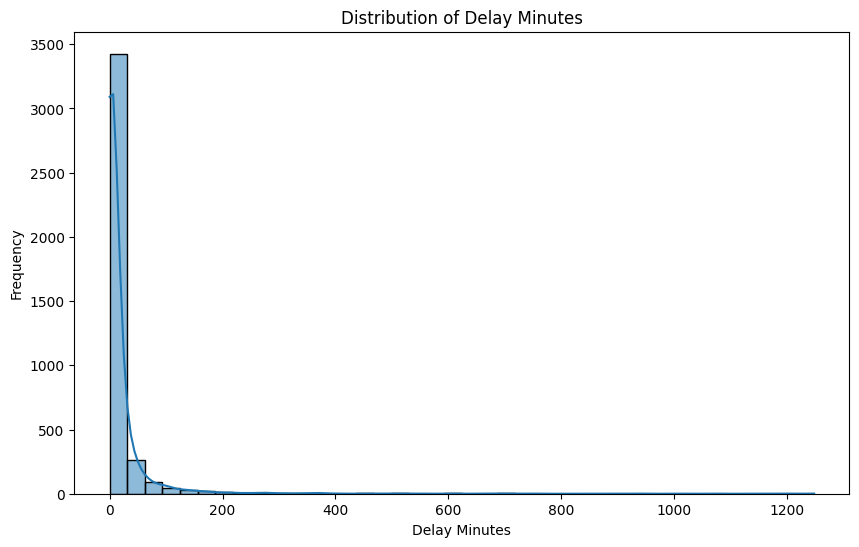

In [7]:
#Distribution of delay minutes
plt.figure(figsize=(10,6))
sns.histplot(df['Delay Mins'], bins=40, kde=True)
plt.title('Distribution of Delay Minutes')
plt.xlabel('Delay Minutes')
plt.ylabel('Frequency')
plt.show()

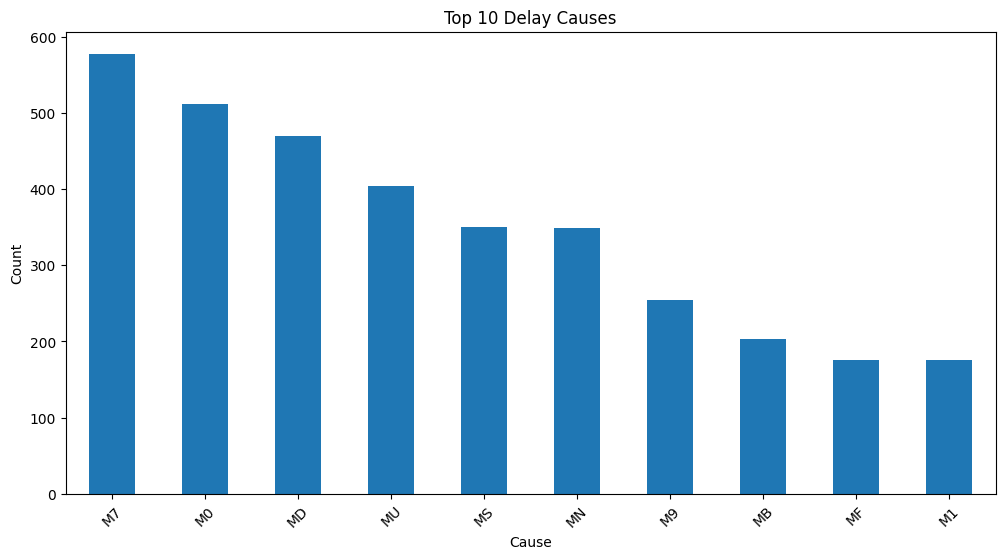

In [8]:
#Top delay causes
plt.figure(figsize=(12,6))
df['Cause'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Delay Causes')
plt.xlabel('Cause')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

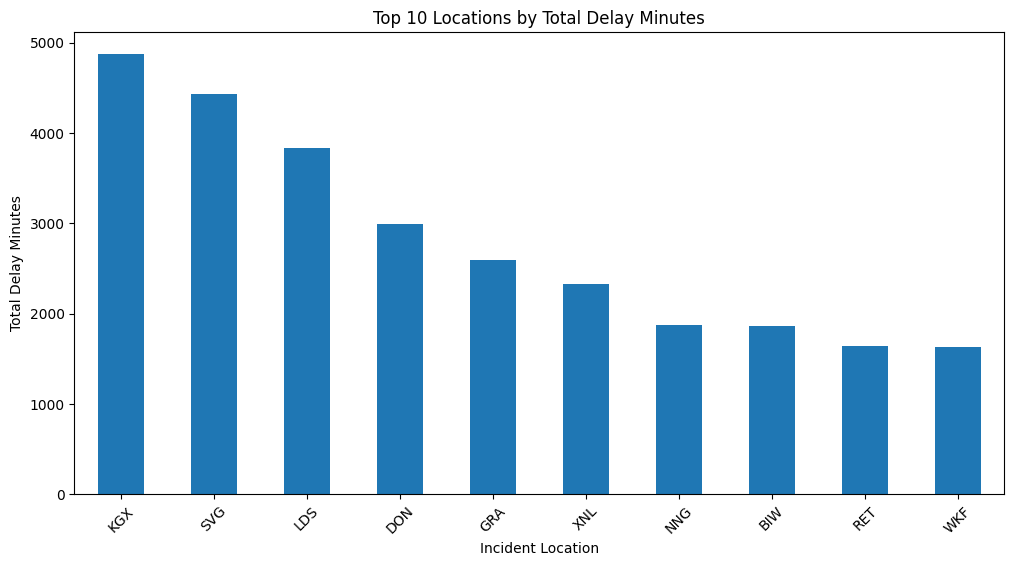

In [9]:
#Top incident location by total delays
top_locations = (
    df.groupby('Incid. Location')['Delay Mins']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
top_locations.plot(kind='bar')
plt.title('Top 10 Locations by Total Delay Minutes')
plt.xlabel('Incident Location')
plt.ylabel('Total Delay Minutes')
plt.xticks(rotation=45)
plt.show()

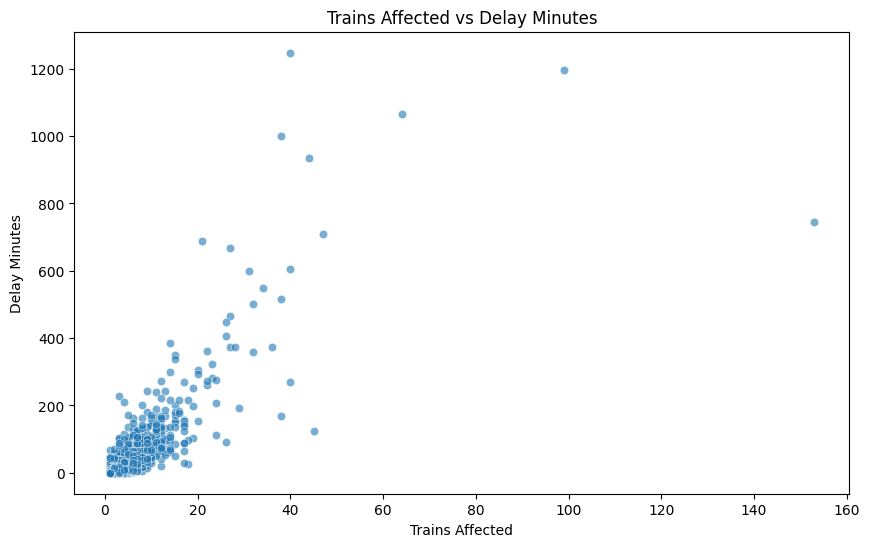

In [10]:
#Trains affected vs delay minutes
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Trains Affect', y='Delay Mins', alpha=0.6)
plt.title('Trains Affected vs Delay Minutes')
plt.xlabel('Trains Affected')
plt.ylabel('Delay Minutes')
plt.show()

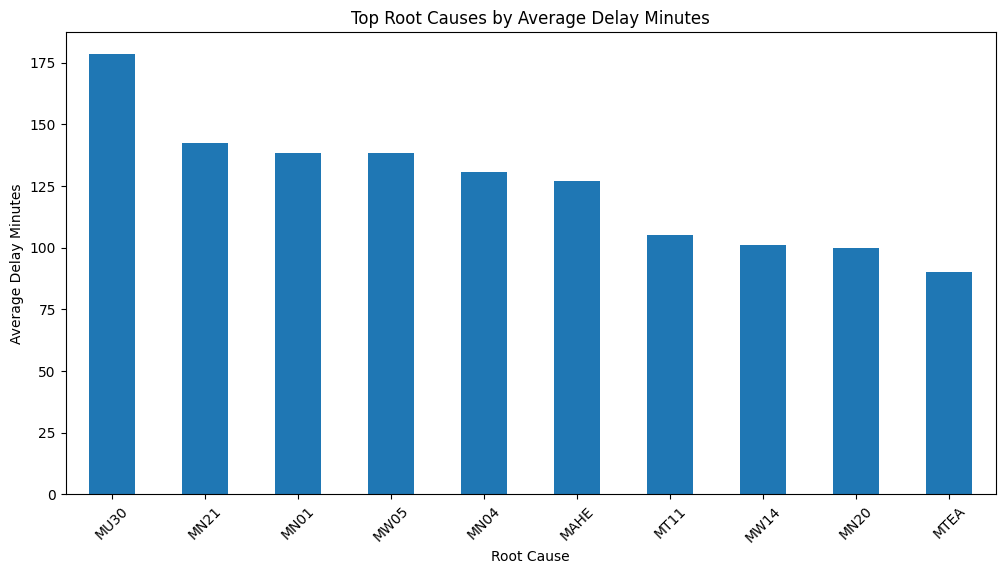

In [11]:
#root causes with highest avg delay
root_delay = (
    df.groupby('Root Cause')['Delay Mins']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
root_delay.plot(kind='bar')
plt.title('Top Root Causes by Average Delay Minutes')
plt.xlabel('Root Cause')
plt.ylabel('Average Delay Minutes')
plt.xticks(rotation=45)
plt.show()

In [12]:
#Feature engineering
threshold = df['Tot. Mins'].quantile(0.75)

df['High_Operational_Pressure'] = (df['Tot. Mins'] > threshold).astype(int)

print(df['High_Operational_Pressure'].value_counts())
print("Threshold used:", threshold)

High_Operational_Pressure
0    2965
1     960
Name: count, dtype: int64
Threshold used: 26.0


In [13]:
#create some engineered features

df['Delay_Per_Train'] = df['Delay Mins'] / (df['Trains Affect'] + 1)
df['Incident_Severity'] = df['Delay Mins'] + df['Inc. Mins Delay Mins'] + df['EQ Mins']
df['Cancellation_Flag'] = (df['Total Canx'] > 0).astype(int)
df['Late_Flag'] = (df['Sig. Lates'] > 0).astype(int)

In [14]:
#select predictors
candidate_features = [
    'Delay Mins',
    'Inc. Mins Delay Mins',
    'Trains Affect',
    'EQ Mins',
    'Capes',
    'Pines',
    'Calvs',
    'FTS',
    'Full Canx',
    'Part Canx',
    'Total Canx',
    'Sig. Lates',
    'Delay_Per_Train',
    'Incident_Severity',
    'Cancellation_Flag',
    'Late_Flag',
    'Month',
    'DayOfWeek',
    'Quarter',
    'Cause',
    'Root Cause',
    'Incid. Location',
    'Equip.',
    'KPI',
    'NR KPI',
    'Company',
    'Region'
]

candidate_features = [col for col in candidate_features if col in df.columns]

X = df[candidate_features].copy()
y = df['High_Operational_Pressure']

In [15]:
#one hot encode categorical varaibles
X = pd.get_dummies(X, drop_first=True)

print(X.shape)
print(X.head())

(3925, 946)
   Delay Mins  Inc. Mins Delay Mins  Trains Affect  EQ Mins  Capes  Pines  \
0         0.0                   8.0              1      8.0    0.0    0.0   
1         2.0                   0.0              1      2.0    0.0    0.0   
2         0.0                   6.0              1      6.0    0.0    0.0   
3         3.0                   0.0              1      3.0    0.0    0.0   
4       181.0                 143.0              9    504.0    2.0    1.0   

   Calvs  FTS  Full Canx  Part Canx  ...  Equip._UNKNOWN  Equip._Undefined  \
0    0.0    0        0.0        0.0  ...           False             False   
1    0.0    0        0.0        0.0  ...           False             False   
2    0.0    0        0.0        0.0  ...           False             False   
3    0.0    0        0.0        0.0  ...           False             False   
4    0.0    0        3.0        0.0  ...           False             False   

   Equip._Unknown  Equip._VARIOUS  KPI_701D  KPI_750  NR

Modelling Phase

In [16]:
#train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(2747, 946) (1178, 946)


In [17]:
#deicison tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("\nDecision Tree Confusion Matrix:\n", confusion_matrix(y_test, dt_pred))
print("\nDecision Tree Classification Report:\n", classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.9864176570458404

Decision Tree Confusion Matrix:
 [[878  12]
 [  4 284]]

Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99       890
           1       0.96      0.99      0.97       288

    accuracy                           0.99      1178
   macro avg       0.98      0.99      0.98      1178
weighted avg       0.99      0.99      0.99      1178



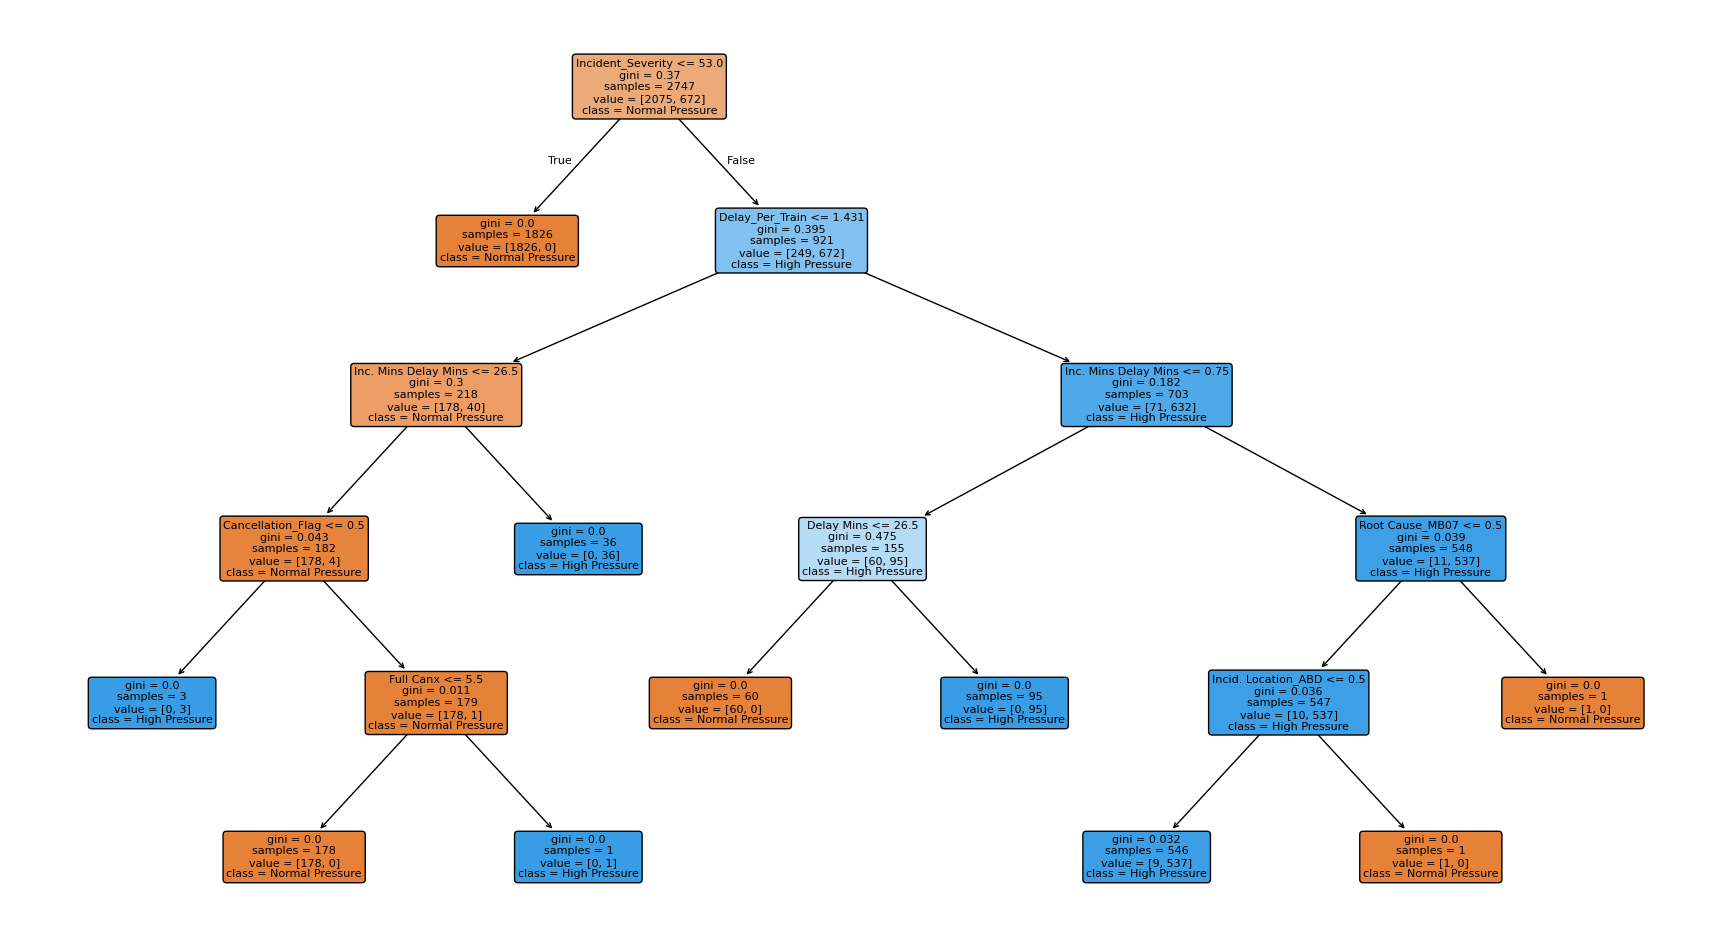

In [18]:
#plot tree

plt.figure(figsize=(22,12))

plot_tree(
    dt_model,
    filled=True,
    feature_names=X.columns,
    class_names=['Normal Pressure', 'High Pressure'],
    rounded=True,
    fontsize=8
)

plt.show()

In [19]:
#check overfitting
train_pred = dt_model.predict(X_train)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, dt_pred)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.9967236985802694
Testing Accuracy: 0.9864176570458404


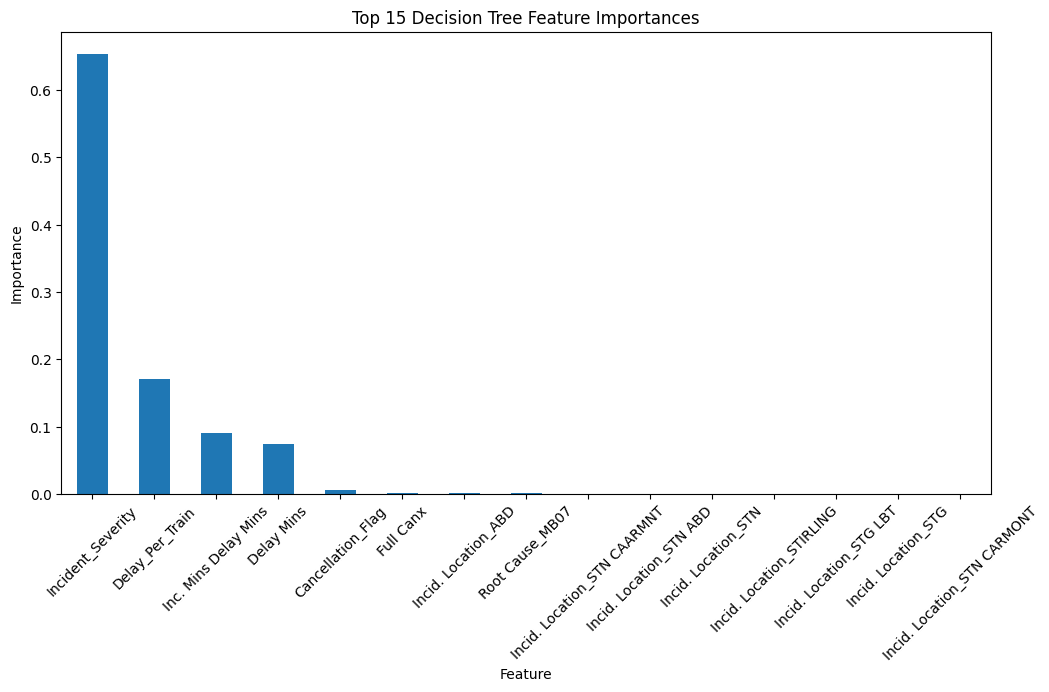

Incident_Severity              0.653480
Delay_Per_Train                0.170807
Inc. Mins Delay Mins           0.090273
Delay Mins                     0.073732
Cancellation_Flag              0.005850
Full Canx                      0.001994
Incid. Location_ABD            0.001936
Root Cause_MB07                0.001929
Incid. Location_STN CAARMNT    0.000000
Incid. Location_STN ABD        0.000000
Incid. Location_STN            0.000000
Incid. Location_STIRLING       0.000000
Incid. Location_STG LBT        0.000000
Incid. Location_STG            0.000000
Incid. Location_STN CARMONT    0.000000
dtype: float64


In [20]:
#feature importance
dt_importance = pd.Series(dt_model.feature_importances_, index=X.columns)
dt_importance = dt_importance.sort_values(ascending=False).head(15)

plt.figure(figsize=(12,6))
dt_importance.plot(kind='bar')
plt.title('Top 15 Decision Tree Feature Importances')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.show()

print(dt_importance)

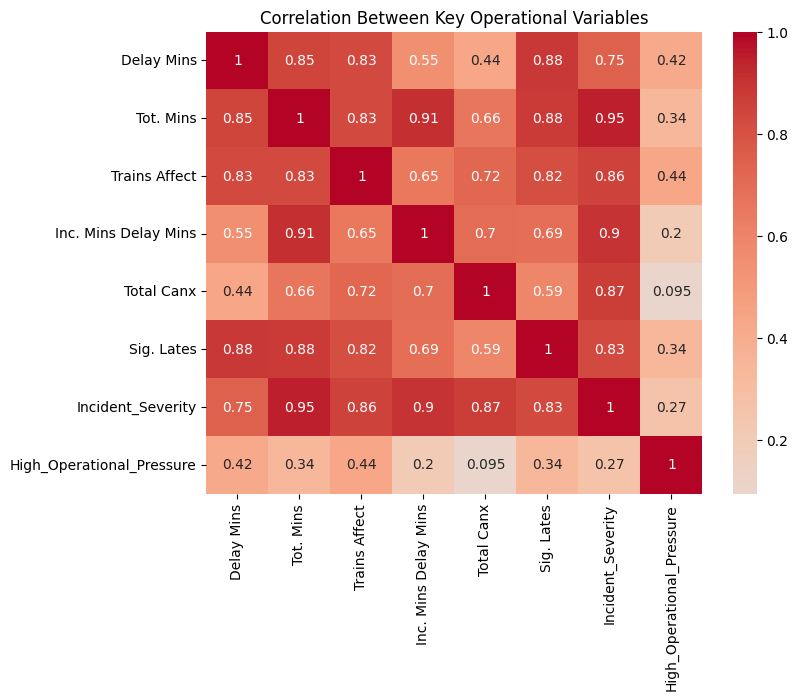

In [21]:
important_cols = [
    'Delay Mins',
    'Tot. Mins',
    'Trains Affect',
    'Inc. Mins Delay Mins',
    'Total Canx',
    'Sig. Lates',
    'Incident_Severity',
    'High_Operational_Pressure'
]

corr = df[important_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)

plt.title("Correlation Between Key Operational Variables")
plt.show()

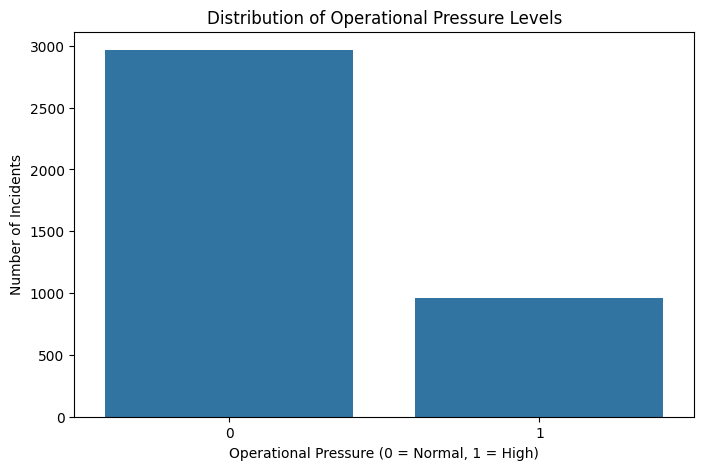

In [22]:
plt.figure(figsize=(8,5))
sns.countplot(x='High_Operational_Pressure', data=df)

plt.title("Distribution of Operational Pressure Levels")
plt.xlabel("Operational Pressure (0 = Normal, 1 = High)")
plt.ylabel("Number of Incidents")

plt.show()

Comparing models


In [23]:
#Logisitc regression

log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print("\nLogistic Regression Confusion Matrix:\n", confusion_matrix(y_test, log_pred))
print("\nLogistic Regression Classification Report:\n", classification_report(y_test, log_pred))

Logistic Regression Accuracy: 1.0

Logistic Regression Confusion Matrix:
 [[890   0]
 [  0 288]]

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       890
           1       1.00      1.00      1.00       288

    accuracy                           1.00      1178
   macro avg       1.00      1.00      1.00      1178
weighted avg       1.00      1.00      1.00      1178



In [24]:
#random forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nRandom Forest Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("\nRandom Forest Classification Report:\n", classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9923599320882852

Random Forest Confusion Matrix:
 [[887   3]
 [  6 282]]

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       890
           1       0.99      0.98      0.98       288

    accuracy                           0.99      1178
   macro avg       0.99      0.99      0.99      1178
weighted avg       0.99      0.99      0.99      1178



                 Model  Accuracy
0        Decision Tree  0.986418
1  Logistic Regression  1.000000
2        Random Forest  0.992360


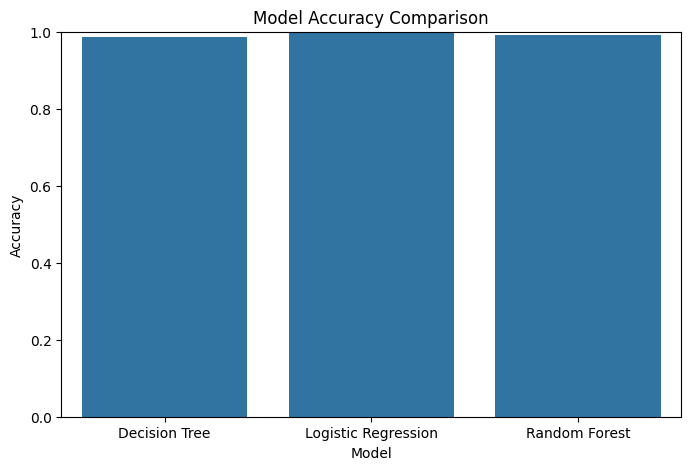

In [25]:
#compare model accuracies

results = pd.DataFrame({
    'Model': ['Decision Tree', 'Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

print(results)

plt.figure(figsize=(8,5))
sns.barplot(data=results, x='Model', y='Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)
plt.show()

In [26]:
#making sure data is datetime

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date']).copy()

In [27]:
#if target doesnt exist

if 'High_Operational_Pressure' not in df.columns:
    threshold = df['Tot. Mins'].quantile(0.75)
    df['High_Operational_Pressure'] = (df['Tot. Mins'] > threshold).astype(int)

In [28]:
#aggregate to daily level
daily = df.groupby('Date').agg({
    'Delay Mins': 'sum',
    'Tot. Mins': 'sum',
    'High_Operational_Pressure': 'max'
}).reset_index()

daily = daily.sort_values('Date').reset_index(drop=True)

In [29]:
#create lagged rolling featurws

daily['prev_day_delay_mins'] = daily['Delay Mins'].shift(1)
daily['prev_day_tot_mins'] = daily['Tot. Mins'].shift(1)
daily['prev_day_high_pressure'] = daily['High_Operational_Pressure'].shift(1)



daily['rolling_3day_delay_avg'] = daily['Delay Mins'].rolling(3).mean().shift(1)
daily['rolling_3day_tot_avg'] = daily['Tot. Mins'].rolling(3).mean().shift(1)

In [30]:
daily = daily.dropna().copy()

In [31]:
#use past info to predict current day pressure
X = daily[
    [
        'prev_day_delay_mins',
        'prev_day_tot_mins',
        'prev_day_high_pressure',
        'rolling_3day_delay_avg',
        'rolling_3day_tot_avg',

    ]
]

y = daily['High_Operational_Pressure']

In [32]:
#train test split without shuffle

split_index = int(len(daily) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]


In [33]:
#random forest

rf_lag = RandomForestClassifier(n_estimators=200, random_state=42)
rf_lag.fit(X_train, y_train)

y_pred_lag = rf_lag.predict(X_test)

print("Lagged Random Forest Accuracy:", accuracy_score(y_test, y_pred_lag))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lag))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lag))


Lagged Random Forest Accuracy: 0.5098039215686274

Confusion Matrix:
 [[68 61]
 [64 62]]

Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.53      0.52       129
           1       0.50      0.49      0.50       126

    accuracy                           0.51       255
   macro avg       0.51      0.51      0.51       255
weighted avg       0.51      0.51      0.51       255




Lagged Random Forest Feature Importance:
 rolling_3day_tot_avg      0.280334
rolling_3day_delay_avg    0.271951
prev_day_tot_mins         0.235458
prev_day_delay_mins       0.197996
prev_day_high_pressure    0.014261
dtype: float64


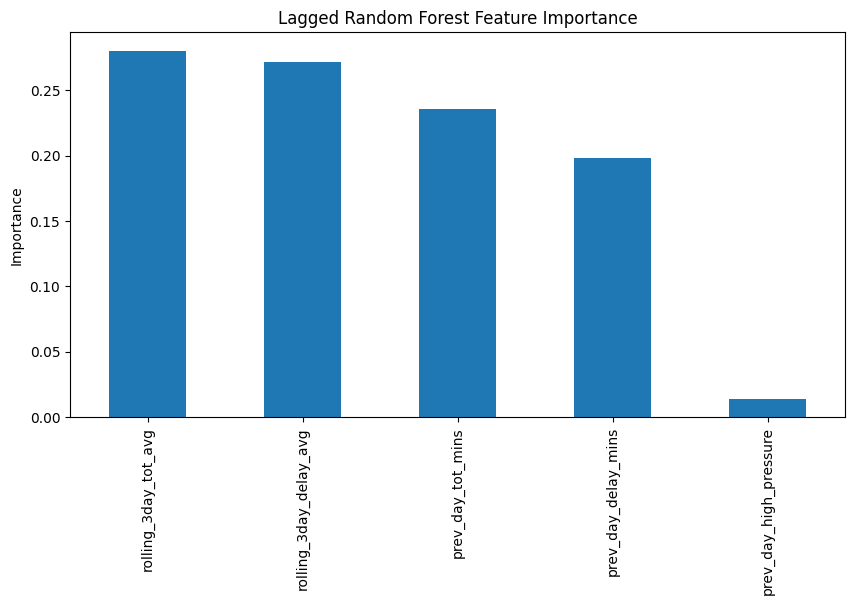

In [34]:
#feature importance
importance = pd.Series(rf_lag.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nLagged Random Forest Feature Importance:\n", importance)
plt.figure(figsize=(10,5))
importance.plot(kind='bar')
plt.title("Lagged Random Forest Feature Importance")
plt.ylabel("Importance")
plt.show()

In [35]:
#quick look at daily data

print("\nDaily forecasting dataset shape:", daily.shape)
print(daily.head())


Daily forecasting dataset shape: (1273, 9)
        Date  Delay Mins  Tot. Mins  High_Operational_Pressure  \
3 2022-04-05        25.0       57.0                          1   
4 2022-04-06        73.0      151.0                          1   
5 2022-04-07        64.0      160.0                          1   
6 2022-04-08        19.0       65.0                          1   
7 2022-04-10        54.0      102.0                          1   

   prev_day_delay_mins  prev_day_tot_mins  prev_day_high_pressure  \
3                184.0              335.0                     1.0   
4                 25.0               57.0                     1.0   
5                 73.0              151.0                     1.0   
6                 64.0              160.0                     1.0   
7                 19.0               65.0                     1.0   

   rolling_3day_delay_avg  rolling_3day_tot_avg  
3               62.000000            117.000000  
4               70.333333            133.333

In [36]:
list(df.columns)

['Date',
 'Cause',
 'Root Cause',
 'Root Cause Descrip.',
 'Incid. Location',
 'Equip.',
 'Delay Mins',
 'Tot. Mins',
 'Inc. Mins Delay Mins',
 'Trains Affect',
 'EQ Mins',
 'Capes',
 'Pines',
 'Calvs',
 'FTS',
 'Full Canx',
 'Part Canx',
 'Total Canx',
 'Sig. Lates',
 'KPI',
 'Bugle Status',
 'NR KPI',
 'Company',
 'Region',
 'Year',
 'Month',
 'DayOfWeek',
 'Quarter',
 'High_Operational_Pressure',
 'Delay_Per_Train',
 'Incident_Severity',
 'Cancellation_Flag',
 'Late_Flag']

In [37]:
#22nd march

In [38]:
print(df['High_Operational_Pressure'].value_counts())
print(df['High_Operational_Pressure'].value_counts(normalize=True))

High_Operational_Pressure
0    2965
1     960
Name: count, dtype: int64
High_Operational_Pressure
0    0.755414
1    0.244586
Name: proportion, dtype: float64


In [39]:
import numpy as np

# avoid divide-by-zero
df['Delay_Per_Train_2'] = df['Tot. Mins'] / (df['Trains Affect'] + 1)

# stronger severity-style interactions
df['Delay_x_Trains'] = df['Delay Mins'] * df['Trains Affect']
df['TotalDelay_x_Trains'] = df['Tot. Mins'] * df['Trains Affect']
df['Incident_Severity_2'] = (
    df['Delay Mins'] +
    df['Tot. Mins'] +
    df['Inc. Mins Delay Mins'] +
    df['Sig. Lates'] * 10 +
    df['Total Canx'] * 20
)

# ratios
df['SigLate_Rate'] = df['Sig. Lates'] / (df['Trains Affect'] + 1)
df['Canx_Rate'] = df['Total Canx'] / (df['Trains Affect'] + 1)

# simple calendar interaction
df['Peak_Month_Flag'] = df['Month'].isin([11, 12, 1, 2]).astype(int)

In [40]:
target = 'High_Operational_Pressure'

drop_cols = [
    target,
    'Date',

    # ORIGINAL leakage
    'Delay Mins',
    'Tot. Mins',
    'Inc. Mins Delay Mins',
    'Sig. Lates',
    'Total Canx',
    'Delay_Per_Train',
    'Incident_Severity',

    # NEW leakage (you created these)
    'Delay_Per_Train_2',
    'Delay_x_Trains',
    'TotalDelay_x_Trains',
    'Incident_Severity_2',
    'SigLate_Rate',
    'Canx_Rate',
    'EQ Mins'
]

X = df.drop(columns=drop_cols, errors='ignore')
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3925, 24)
y shape: (3925,)


In [41]:
X = pd.get_dummies(X, drop_first=True)

print("Encoded X shape:", X.shape)

Encoded X shape: (3925, 1195)


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.8547770700636943

Confusion Matrix:
 [[510  83]
 [ 31 161]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.86      0.90       593
           1       0.66      0.84      0.74       192

    accuracy                           0.85       785
   macro avg       0.80      0.85      0.82       785
weighted avg       0.87      0.85      0.86       785



Trains Affect                                          0.283935
Late_Flag                                              0.157920
Pines                                                  0.029422
KPI_750                                                0.022484
Cancellation_Flag                                      0.019305
Part Canx                                              0.017361
Root Cause Descrip._800/801 DIESEL ENGINE / GU         0.017254
Cause_MN                                               0.016773
Full Canx                                              0.016515
NR KPI_Fleet                                           0.016244
Root Cause_MT11                                        0.016135
Root Cause Descrip._ON-BOARD HABD, INCLUDING CABLES    0.015808
Cause_MP                                               0.015687
Root Cause_MD03                                        0.015524
KPI_701D                                               0.015468
dtype: float64


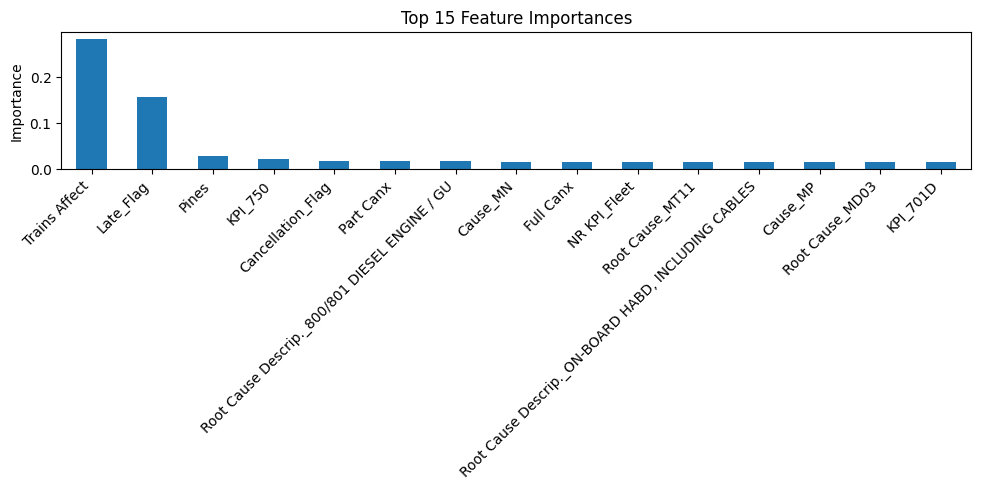

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

print(importance)

plt.figure(figsize=(10, 5))
importance.plot(kind='bar')
plt.title('Top 15 Feature Importances')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [45]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, gb_pred))
print("\nClassification Report:\n", classification_report(y_test, gb_pred))

Gradient Boosting Accuracy: 0.9082802547770701

Confusion Matrix:
 [[565  28]
 [ 44 148]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.95      0.94       593
           1       0.84      0.77      0.80       192

    accuracy                           0.91       785
   macro avg       0.88      0.86      0.87       785
weighted avg       0.91      0.91      0.91       785



In [46]:
train_pred = rf_model.predict(X_train)
test_pred = rf_model.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, rf_pred))
print("Gap:", accuracy_score(y_train, train_pred) - accuracy_score(y_test, rf_pred))

Train Accuracy: 0.8624203821656051
Test Accuracy: 0.8547770700636943
Gap: 0.007643312101910826


In [47]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')
print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Std CV Accuracy:", cv_scores.std())

CV Scores: [0.8522293  0.86242038 0.83566879 0.85350318 0.84203822]
Mean CV Accuracy: 0.849171974522293
Std CV Accuracy: 0.009347228702086183


In [48]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

dt_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, dt_pred))
print("\nClassification Report:\n", classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.8853503184713376

Confusion Matrix:
 [[559  34]
 [ 56 136]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.94      0.93       593
           1       0.80      0.71      0.75       192

    accuracy                           0.89       785
   macro avg       0.85      0.83      0.84       785
weighted avg       0.88      0.89      0.88       785



In [49]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

dt_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, dt_pred))
print("\nClassification Report:\n", classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.8853503184713376

Confusion Matrix:
 [[559  34]
 [ 56 136]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.94      0.93       593
           1       0.80      0.71      0.75       192

    accuracy                           0.89       785
   macro avg       0.85      0.83      0.84       785
weighted avg       0.88      0.89      0.88       785



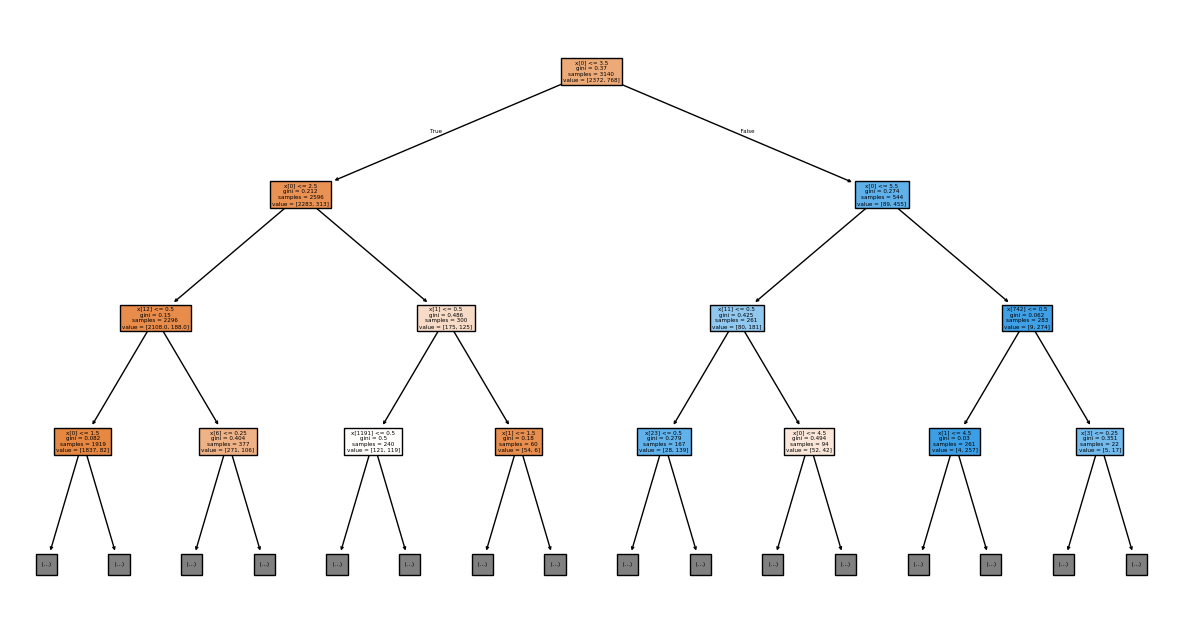

In [50]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))
plot_tree(dt_model, max_depth=3, filled=True)
plt.show()

In [51]:
import pandas as pd

importance = pd.Series(dt_model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False).head(10)

print(importance)

Trains Affect          0.720488
Late_Flag              0.053494
Capes                  0.024912
Part Canx              0.024771
Month                  0.023960
DayOfWeek              0.023230
Cancellation_Flag      0.022688
Year                   0.016760
Calvs                  0.009570
Incid. Location_KGX    0.009306
dtype: float64


In [55]:
# Aggregate to daily level
daily = df.groupby('Date').agg({
    'Delay Mins': 'sum',
    'Tot. Mins': 'sum',
    'Trains Affect': 'sum',
    'Total Canx': 'sum',
    'Sig. Lates': 'sum'
}).reset_index()

daily = daily.sort_values('Date').reset_index(drop=True)

# Define high pressure at DAILY level using daily total delay
daily_threshold = daily['Tot. Mins'].quantile(0.75)
daily['High_Pressure_Day'] = (daily['Tot. Mins'] > daily_threshold).astype(int)

print(f"Daily threshold: {daily_threshold}")
print(daily['High_Pressure_Day'].value_counts())

Daily threshold: 103.0
High_Pressure_Day
0    959
1    317
Name: count, dtype: int64


In [56]:
daily['prev_day_delay'] = daily['Tot. Mins'].shift(1)
daily['prev_day_trains'] = daily['Trains Affect'].shift(1)
daily['prev_day_canx'] = daily['Total Canx'].shift(1)
daily['prev_day_pressure'] = daily['High_Pressure_Day'].shift(1)
daily['rolling_3day_avg'] = daily['Tot. Mins'].rolling(3).mean().shift(1)
daily['rolling_7day_avg'] = daily['Tot. Mins'].rolling(7).mean().shift(1)

daily = daily.dropna().copy()

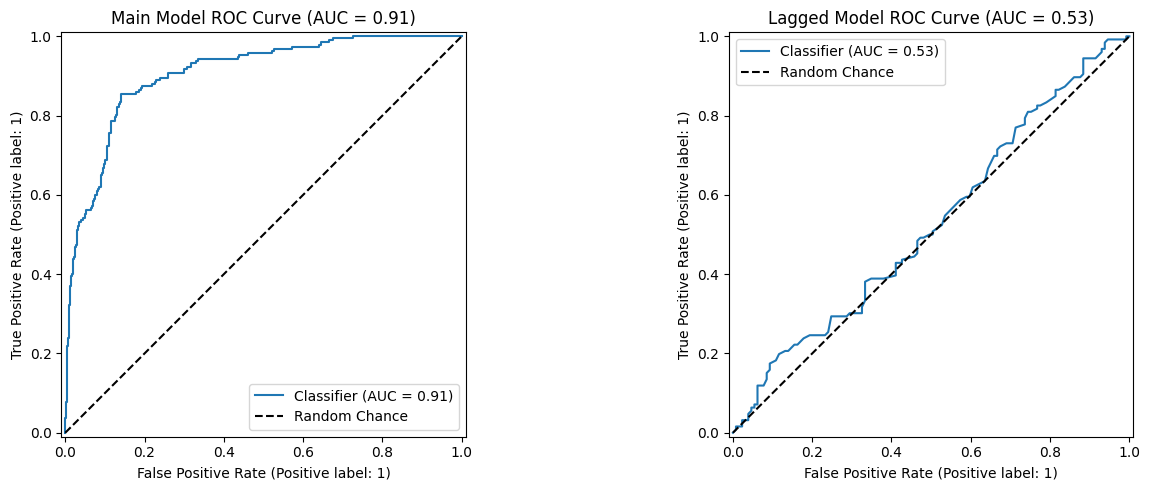

In [59]:
# Plot both ROC curves together for comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Main model
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0])
axes[0].set_title(f'Main Model ROC Curve (AUC = {auc_score:.2f})')
axes[0].plot([0,1], [0,1], 'k--', label='Random Chance')
axes[0].legend()

# Lagged model
RocCurveDisplay.from_predictions(y_test_lagged, y_proba_lag, ax=axes[1])
axes[1].set_title(f'Lagged Model ROC Curve (AUC = {auc_lag:.2f})')
axes[1].plot([0,1], [0,1], 'k--', label='Random Chance')
axes[1].legend()

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

In [60]:
# Redefine target at daily level properly
daily = df.groupby('Date').agg({
    'Delay Mins': 'sum',
    'Tot. Mins': 'sum',
    'Trains Affect': 'sum',
    'Total Canx': 'sum',
    'Sig. Lates': 'sum'
}).reset_index()

daily = daily.sort_values('Date').reset_index(drop=True)

# Define high pressure at DAILY level
daily_threshold = daily['Tot. Mins'].quantile(0.75)
daily['High_Pressure_Day'] = (daily['Tot. Mins'] > daily_threshold).astype(int)

print(f"Daily threshold: {daily_threshold:.1f} mins")
print(daily['High_Pressure_Day'].value_counts())

# Lag features
daily['prev_day_delay'] = daily['Tot. Mins'].shift(1)
daily['prev_day_trains'] = daily['Trains Affect'].shift(1)
daily['prev_day_canx'] = daily['Total Canx'].shift(1)
daily['prev_day_pressure'] = daily['High_Pressure_Day'].shift(1)
daily['rolling_3day_avg'] = daily['Tot. Mins'].rolling(3).mean().shift(1)
daily['rolling_7day_avg'] = daily['Tot. Mins'].rolling(7).mean().shift(1)

daily = daily.dropna().copy()

# Features and target
X_lag2 = daily[['prev_day_delay', 'prev_day_trains', 'prev_day_canx',
                 'prev_day_pressure', 'rolling_3day_avg', 'rolling_7day_avg']]
y_lag2 = daily['High_Pressure_Day']

# Chronological split
split_index = int(len(daily) * 0.8)
X_train_lag2 = X_lag2.iloc[:split_index]
X_test_lag2 = X_lag2.iloc[split_index:]
y_train_lag2 = y_lag2.iloc[:split_index]
y_test_lag2 = y_lag2.iloc[split_index:]

# Train
rf_lag2 = RandomForestClassifier(n_estimators=200, random_state=42)
rf_lag2.fit(X_train_lag2, y_train_lag2)
y_pred_lag2 = rf_lag2.predict(X_test_lag2)
y_proba_lag2 = rf_lag2.predict_proba(X_test_lag2)[:, 1]

# Results
print("\nFixed Lagged Model Accuracy:", accuracy_score(y_test_lag2, y_pred_lag2))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_lag2, y_pred_lag2))
print("\nClassification Report:\n", classification_report(y_test_lag2, y_pred_lag2))
print(f"\nROC-AUC: {roc_auc_score(y_test_lag2, y_proba_lag2):.4f}")

Daily threshold: 103.0 mins
High_Pressure_Day
0    959
1    317
Name: count, dtype: int64

Fixed Lagged Model Accuracy: 0.7440944881889764

Confusion Matrix:
 [[186   8]
 [ 57   3]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.96      0.85       194
           1       0.27      0.05      0.08        60

    accuracy                           0.74       254
   macro avg       0.52      0.50      0.47       254
weighted avg       0.65      0.74      0.67       254


ROC-AUC: 0.6124


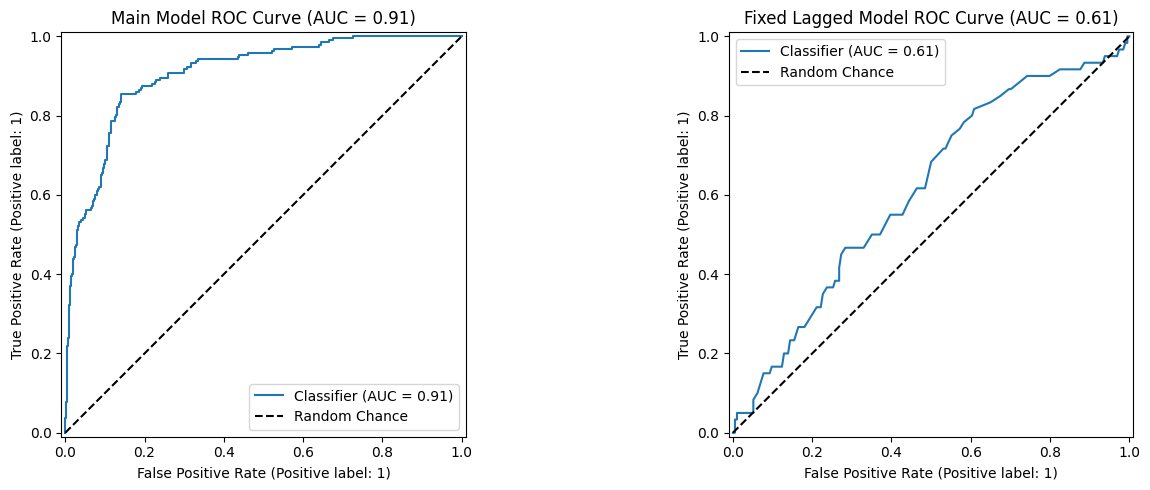

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Main model stays the same
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0])
axes[0].set_title(f'Main Model ROC Curve (AUC = {auc_score:.2f})')
axes[0].plot([0,1], [0,1], 'k--', label='Random Chance')
axes[0].legend()

# Fixed lagged model
auc_lag2 = roc_auc_score(y_test_lag2, y_proba_lag2)
RocCurveDisplay.from_predictions(y_test_lag2, y_proba_lag2, ax=axes[1])
axes[1].set_title(f'Fixed Lagged Model ROC Curve (AUC = {auc_lag2:.2f})')
axes[1].plot([0,1], [0,1], 'k--', label='Random Chance')
axes[1].legend()

plt.tight_layout()
plt.savefig('roc_curves_fixed.png', dpi=150)
plt.show()

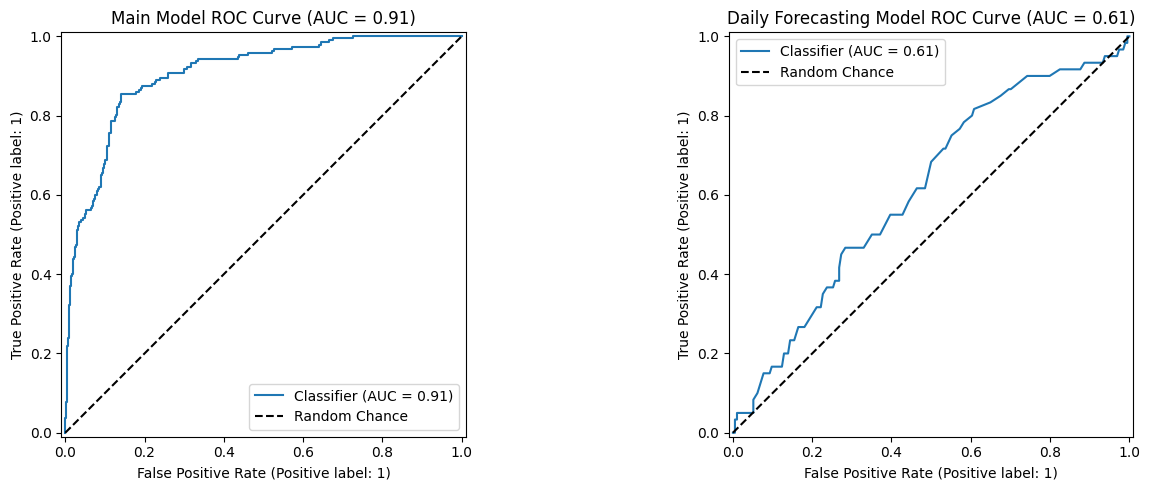

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Main model
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0])
axes[0].set_title(f'Main Model ROC Curve (AUC = 0.91)')
axes[0].plot([0,1], [0,1], 'k--', label='Random Chance')
axes[0].legend()

# Fixed lagged model
RocCurveDisplay.from_predictions(y_test_lag2, y_proba_lag2, ax=axes[1])
axes[1].set_title(f'Daily Forecasting Model ROC Curve (AUC = 0.61)')
axes[1].plot([0,1], [0,1], 'k--', label='Random Chance')
axes[1].legend()

plt.tight_layout()
plt.savefig('roc_curves_final.png', dpi=150)
plt.show()